# Configurações, Caminhos e Importações

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import glob
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.colab import drive

# Seeds para reprodutibilidade
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

drive.mount('/content/drive')

# --- CONFIGURAÇÃO DE CAMINHOS ---
dataset_path = '/content/drive/MyDrive/TCC/PKG - Osteosarcoma Tumor Assessment'
csv_path = '/content/drive/MyDrive/TCC/ML_Features_1144.csv'
save_model_path = '/content/drive/MyDrive/TCC/Modelos_Osteosarcoma'

os.makedirs(save_model_path, exist_ok=True)

# NOMES PARA A EFFICIENTNET B2
checkpoint_path = os.path.join(save_model_path, 'melhor_modelo_B2_3classes_CLAHE_temp.keras')
final_model_name = os.path.join(save_model_path, 'EfficientNetB2_Osteosarcoma_3classes_CLAHE_Final.keras')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

Mounted at /content/drive


# Função CLAHE (Espaço YUV)

In [ ]:
def apply_clahe_yuv(image):
    """
    Converte RGB -> YUV, aplica CLAHE no canal Y, e retorna para RGB.
    """
    img_uint8 = image.astype('uint8')

    # 1. Converter de RGB para YUV
    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)

    # 2. Aplicar CLAHE no canal de Luminância (Y)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    # 3. Converter de volta para RGB
    img_final = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    return img_final.astype('float32')

# Mapeamento e Agrupamento de Classes

In [ ]:
print("Iniciando carregamento e agrupamento (3 Classes)...")
df_original = pd.read_csv(csv_path)

# Criando cópia
df_copia = df_original.copy()

# ==============================================================================
# ALTERAÇÃO DO DATASET: Mesclando 'viable: non-viable' em 'Viable'
# ==============================================================================
df_copia['classification'] = df_copia['classification'].replace('viable: non-viable', 'Viable')

print("\nDistribuição para a EfficientNetB2:")
print(df_copia['classification'].value_counts())

all_image_paths = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
all_image_paths += glob.glob(os.path.join(dataset_path, '**', '*.JPG'), recursive=True)

normalized_path_lookup = {}
for p in all_image_paths:
    base = os.path.basename(p)
    name_no_ext = os.path.splitext(base)[0]
    norm_name = name_no_ext.lower().replace(" ", "").replace("-", "").replace("_", "")
    normalized_path_lookup[norm_name] = p

def get_full_path_robust(image_name):
    if pd.isna(image_name): return None
    norm_csv_name = str(image_name).lower().replace(" ", "").replace("-", "").replace("_", "")
    return normalized_path_lookup.get(norm_csv_name)

df_copia['full_path'] = df_copia['image.name'].apply(get_full_path_robust)
df_final = df_copia.dropna(subset=['full_path']).copy()

print(f"\nTotal de imagens mapeadas: {len(df_final)} / 1144")

Iniciando carregamento e agrupamento (3 Classes)...

Distribuição para a EfficientNetB2:
classification
Non-Tumor           536
Viable              345
Non-Viable-Tumor    263
Name: count, dtype: int64

Total de imagens mapeadas: 1144 / 1144


# Divisão e Geradores

In [ ]:
# Divisão (70/15/15)
train_df, temp_df = train_test_split(
    df_final, train_size=0.7, stratify=df_final['classification'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['classification'], random_state=RANDOM_SEED
)

# Gerador com CLAHE
datagen = ImageDataGenerator(preprocessing_function=apply_clahe_yuv)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 800 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.


# Arquitetura EfficientNetB2 e Treinamento

In [ ]:
def build_model_osteo_b2(num_classes=3):

    base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model_osteo_b2(num_classes=3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando Treinamento (EfficientNetB2 | 3 Classes | CLAHE YUV)...")
history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

model.save(final_model_name)
print(f"Treinamento concluído! Modelo salvo em: {final_model_name}")

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando Treinamento (EfficientNetB2 | 3 Classes | CLAHE YUV)...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5058 - loss: 1.0248 
Epoch 1: val_loss improved from None to 0.62685, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_B2_3classes_CLAHE_temp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_B2_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 419s 15s/step - accuracy: 0.6062 - loss: 0.8679 - val_accuracy: 0.7674 - val_loss: 0.6269
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7772 - loss: 0.5661
Epoch 2: val_loss improved from 0.62685 to 0.45248, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_B2_3classes_CLAHE_temp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_B2_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━

# Avaliação Final

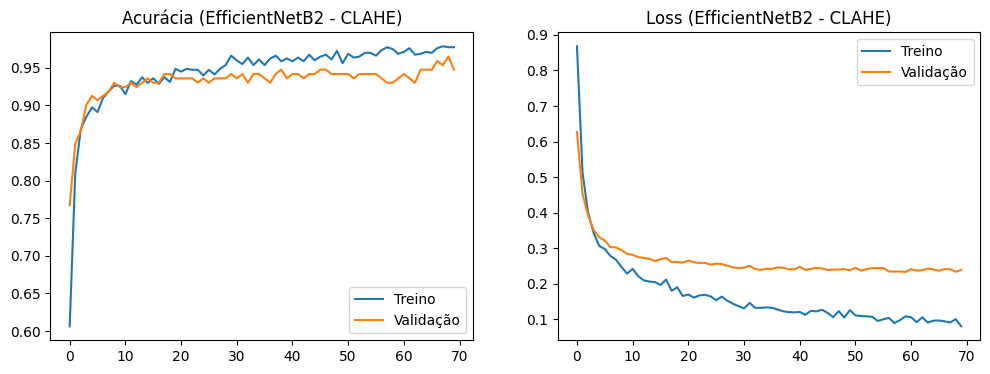

6/6 ━━━━━━━━━━━━━━━━━━━━ 61s 10s/step

--- RELATÓRIO DE CLASSIFICAÇÃO (EfficientNetB2) ---
                  precision    recall  f1-score   support

       Non-Tumor     0.9753    0.9753    0.9753        81
Non-Viable-Tumor     0.9512    1.0000    0.9750        39
          Viable     0.9800    0.9423    0.9608        52

        accuracy                         0.9709       172
       macro avg     0.9688    0.9725    0.9704       172
    weighted avg     0.9713    0.9709    0.9708       172



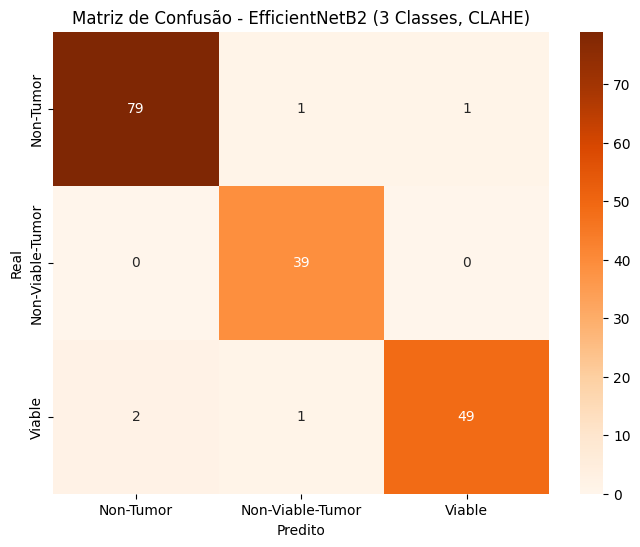

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Gráficos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia (EfficientNetB2 - CLAHE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss (EfficientNetB2 - CLAHE)')
plt.legend()
plt.show()

# Predição
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Relatório
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (EfficientNetB2) ---")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# Matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - EfficientNetB2 (3 Classes, CLAHE)')
plt.show()